In [100]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [101]:
%matplotlib inline

In [102]:
df = pd.read_csv("/Users/samirang/Desktop/Forensics Project/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")
df.columns = df.columns.str.strip()
df['Total Packets'] = df['Total Fwd Packets'] + df['Total Backward Packets']
df['Total Bytes'] = df['Total Length of Fwd Packets'] + df['Total Length of Bwd Packets']


In [103]:
print(df.head())
print(df.shape)

   Destination Port  Flow Duration  Total Fwd Packets  Total Backward Packets  \
0             54865              3                  2                       0   
1             55054            109                  1                       1   
2             55055             52                  1                       1   
3             46236             34                  1                       1   
4             54863              3                  2                       0   

   Total Length of Fwd Packets  Total Length of Bwd Packets  \
0                           12                            0   
1                            6                            6   
2                            6                            6   
3                            6                            6   
4                           12                            0   

   Fwd Packet Length Max  Fwd Packet Length Min  Fwd Packet Length Mean  \
0                      6                      6            

In [104]:
df["Destination Port"].value_counts().head(10)

80      136951
53       31950
443      13485
8080       510
123        362
22         342
137        274
389        261
88         173
21         167
Name: Destination Port, dtype: int64

In [105]:
count_ddos = (df['Label'] != "BENIGN").sum()
print("DDoS Flows: ", count_ddos)
count_benign = (df['Label'] == "BENIGN").sum()
print("Benign Flows: ",count_benign)

DDoS Flows:  128027
Benign Flows:  97718


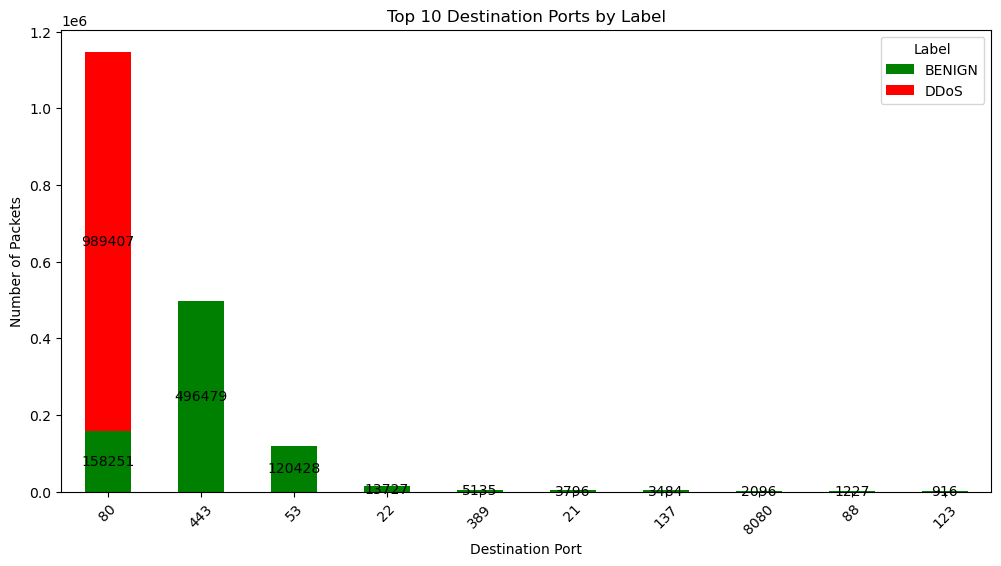

In [106]:
top_ports = df['Destination Port'].value_counts().head(10).index

counts = df[df['Destination Port'].isin(top_ports)].groupby(['Destination Port','Label'])['Total Packets'].sum().unstack(fill_value=0)

counts['total'] = counts.sum(axis=1)
counts = counts.sort_values(by='total', ascending=False)
counts = counts.drop(columns='total')

ax = counts.plot(kind='bar', stacked=True, color=['green','red'], figsize=(12,6))

plt.xlabel('Destination Port')
plt.ylabel('Number of Packets')
plt.title('Top 10 Destination Ports by Label')
plt.xticks(rotation=45)
plt.legend(title='Label')

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(
            p.get_x() + p.get_width()/2,
            p.get_y() + height/2,
            int(height),
            ha='center', va='center', fontsize=10, color='black'
        )

plt.show()



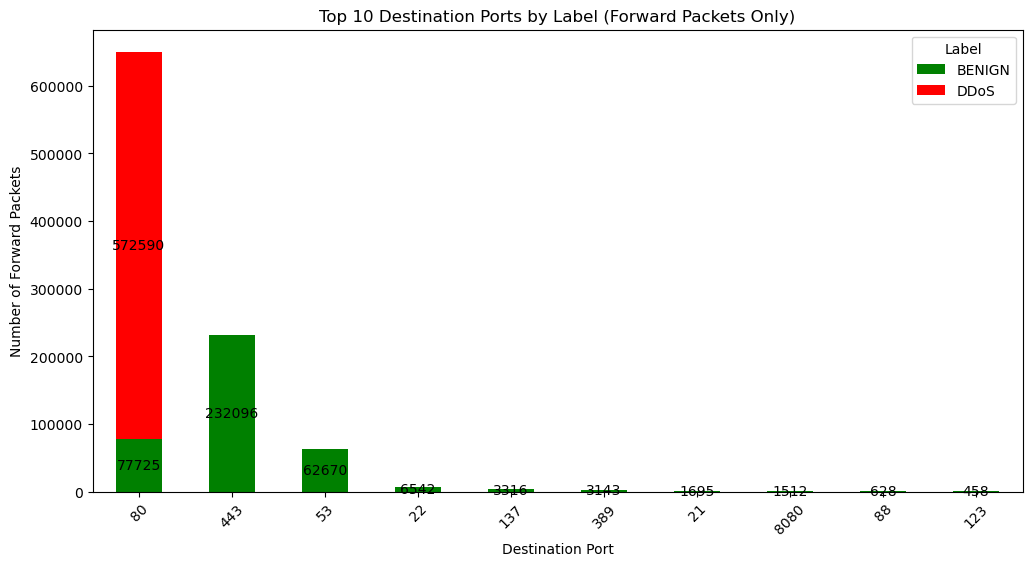

In [107]:
top_ports = df['Destination Port'].value_counts().head(10).index

counts = df[df['Destination Port'].isin(top_ports)].groupby(['Destination Port','Label'])['Total Fwd Packets'].sum().unstack(fill_value=0)

counts['total'] = counts.sum(axis=1)
counts = counts.sort_values(by='total', ascending=False)
counts = counts.drop(columns='total')

ax = counts.plot(kind='bar', stacked=True, color=['green','red'], figsize=(12,6))

plt.xlabel('Destination Port')
plt.ylabel('Number of Forward Packets')
plt.title('Top 10 Destination Ports by Label (Forward Packets Only)')
plt.xticks(rotation=45)
plt.legend(title='Label')

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(
            p.get_x() + p.get_width()/2,
            p.get_y() + height/2,
            int(height),
            ha='center', va='center', fontsize=10, color='black'
        )

plt.show()

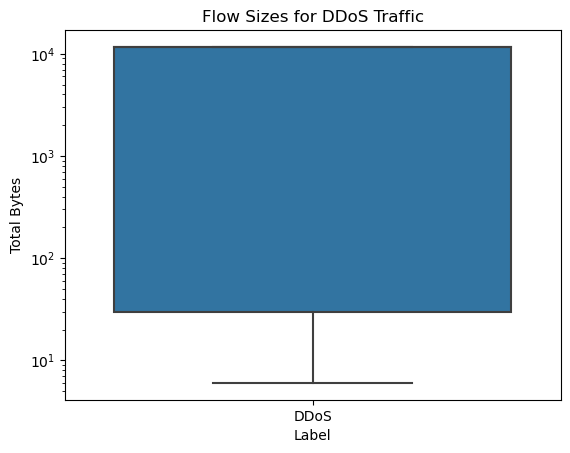

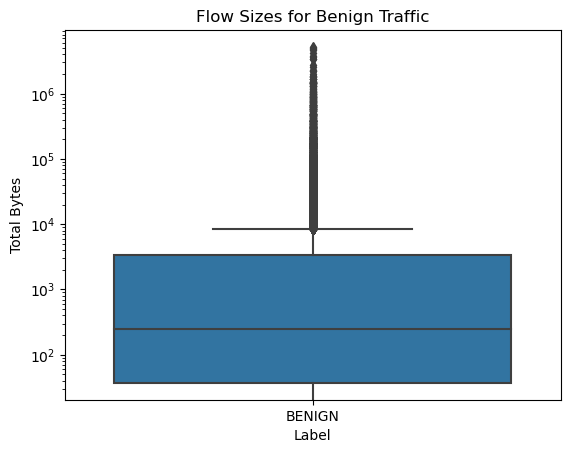

In [108]:
import seaborn as sns

sns.boxplot(x='Label', y='Total Bytes', data=df[df['Label']=='DDoS'])
plt.yscale('log')
plt.title('Flow Sizes for DDoS Traffic')
plt.show()

sns.boxplot(x='Label', y='Total Bytes', data=df[df['Label']=='BENIGN'])
plt.yscale('log')
plt.title('Flow Sizes for Benign Traffic')
plt.show()

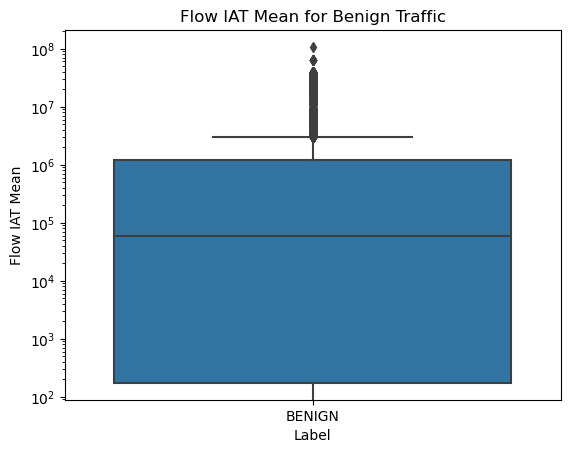

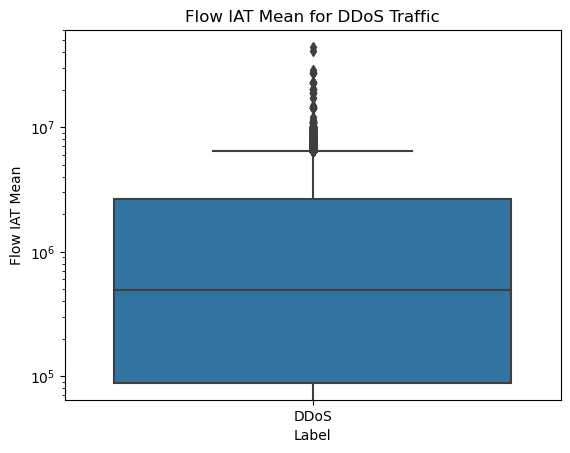

In [109]:
sns.boxplot(x='Label', y='Flow IAT Mean', data=df[df['Label']=='BENIGN'])
plt.yscale('log')
plt.title('Flow IAT Mean for Benign Traffic')
plt.show()

sns.boxplot(x='Label', y='Flow IAT Mean', data=df[df['Label']=='DDoS'])
plt.yscale('log')
plt.title('Flow IAT Mean for DDoS Traffic')
plt.show()


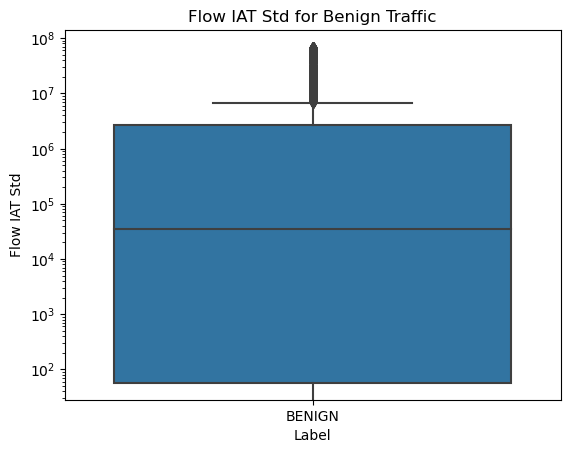

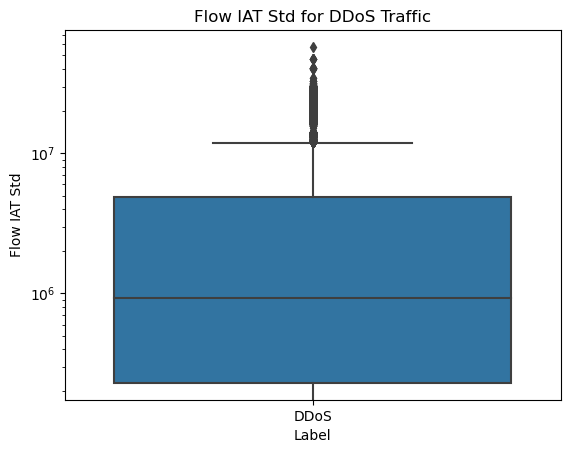

In [110]:
sns.boxplot(x='Label', y='Flow IAT Std', data=df[df['Label']=='BENIGN'])
plt.yscale('log')
plt.title('Flow IAT Std for Benign Traffic')
plt.show()

sns.boxplot(x='Label', y='Flow IAT Std', data=df[df['Label']=='DDoS'])
plt.yscale('log')
plt.title('Flow IAT Std for DDoS Traffic')
plt.show()

In [111]:
ddos = df[df["Label"] == "DDoS"]
benign = df[df["Label"] == "BENIGN"]

ddos_threshold = ddos["Flow Duration"].quantile(0.95)
benign_threshold = benign["Flow Duration"].quantile(0.95)

ddos_spread = ddos[ddos["Flow Duration"] >= ddos_threshold]
benign_spread = benign[benign["Flow Duration"] >= benign_threshold]



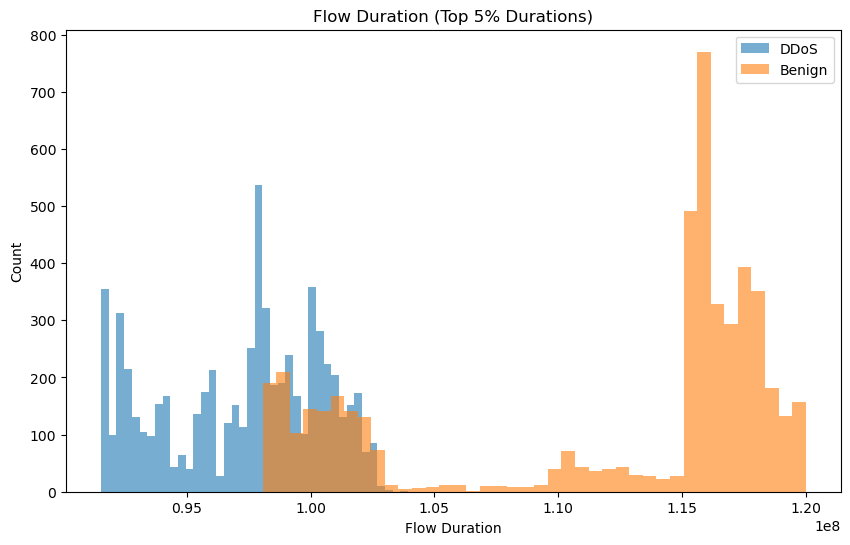

In [112]:
plt.figure(figsize=(10, 6))

plt.hist(ddos_spread["Flow Duration"], bins=40, alpha=0.6, label="DDoS")
plt.hist(benign_spread["Flow Duration"], bins=40, alpha=0.6, label="Benign")

plt.xlabel("Flow Duration")
plt.ylabel("Count")
plt.title("Flow Duration (Top 5% Durations)")
plt.legend()
plt.show()


In [113]:
print(df["Label"].unique())

['BENIGN' 'DDoS']


In [118]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

df = pd.read_csv("/Users/samirang/Desktop/Forensics Project/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")  # Replace with your filename
print("Initial dataframe shape:", df.shape)
df.columns = df.columns.str.strip()
print("Label counts:\n", df["Label"].value_counts())

df["Label"] = df["Label"].str.strip()  # remove whitespace
df = df[df["Label"].isin(["BENIGN", "DDoS"])]
print("After filtering:", df.shape)
print("Label counts:\n", df["Label"].value_counts())

df.replace([np.inf, -np.inf], np.nan, inplace=True)

features = df.drop("Label", axis=1).apply(pd.to_numeric, errors='coerce')

df_clean = pd.concat([features, df["Label"]], axis=1).dropna()
print("After cleaning NaN/infinity/strings:", df_clean.shape)

X = df_clean.drop("Label", axis=1).clip(upper=1e9)
y = df_clean["Label"].map({"BENIGN": 0, "DDoS": 1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Initial dataframe shape: (225745, 79)
Label counts:
 DDoS      128027
BENIGN     97718
Name: Label, dtype: int64
After filtering: (225745, 79)
Label counts:
 DDoS      128027
BENIGN     97718
Name: Label, dtype: int64
After cleaning NaN/infinity/strings: (225711, 79)
Training samples: 180568
Testing samples: 45143
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19538
           1       1.00      1.00      1.00     25605

    accuracy                           1.00     45143
   macro avg       1.00      1.00      1.00     45143
weighted avg       1.00      1.00      1.00     45143

Confusion Matrix:
[[19536     2]
 [    3 25602]]
